<a href="https://colab.research.google.com/github/njokinjuguna/ml-learning-labs/blob/main/ANN_for_bank_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,classification_report

In [ ]:
#data loading
df=pd.read_csv('Churn_Modelling.csv')
df.shape

(10000, 14)

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Data exploration and cleaning

In [ ]:
#Separate features and target
y = df['Exited']
y.value_counts()

,count
Exited,
0,7963
1,2037


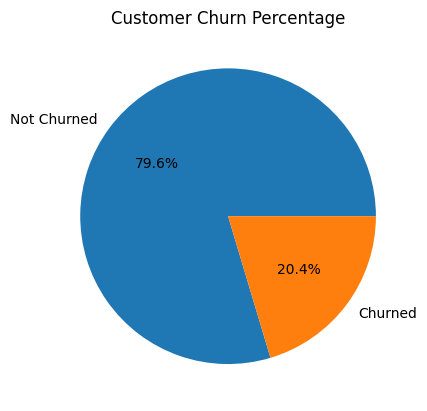

In [ ]:
#from the above we realise the data is imbalanced...lets visualize well in a graph
y.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Not Churned', 'Churned']
)
plt.title('Customer Churn Percentage')
plt.ylabel('')
plt.show()

In [ ]:
#Drop unnecessary columns + target from features
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
df.iloc[:10]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [ ]:
#Gender encode
# 0=Female,1= Male
le=LabelEncoder()
X['Gender']=le.fit_transform(X['Gender'])
X.iloc[:10]


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,0,42,2,0.00,1,1,1,101348.88
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58
2,502,France,0,42,8,159660.80,3,1,0,113931.57
3,699,France,0,39,1,0.00,2,0,0,93826.63
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10
5,645,Spain,1,44,8,113755.78,2,1,0,149756.71
6,822,France,1,50,7,0.00,2,1,1,10062.80
7,376,Germany,0,29,4,115046.74,4,1,0,119346.88
8,501,France,1,44,4,142051.07,2,0,1,74940.50
9,684,France,1,27,2,134603.88,1,1,1,71725.73


In [ ]:
#Geography--one-hot encoding
df=pd.get_dummies(X,columns=['Geography'])
df.iloc[:10]

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,False,True
5,645,1,44,8,113755.78,2,1,0,149756.71,False,False,True
6,822,1,50,7,0.00,2,1,1,10062.80,True,False,False
7,376,0,29,4,115046.74,4,1,0,119346.88,False,True,False
8,501,1,44,4,142051.07,2,0,1,74940.50,True,False,False
9,684,1,27,2,134603.88,1,1,1,71725.73,True,False,False


In [ ]:
#convert geography to int
for col in df.columns:
    if "Geography_" in col:
        df[col] = df[col].astype(int)

In [ ]:
#drop missing values
df.isna().sum()

,0
CreditScore,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0
Geography_France,0


In [ ]:
df.dtypes

,0
CreditScore,int64
Gender,int64
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64
Geography_France,int64


In [ ]:
#data spliting
X_train,X_test,y_train,y_test=train_test_split(df,y,test_size=0.2,random_state=5)

In [ ]:
# #scaling the data
cols_to_scale = [
    'CreditScore',
    'Balance',
    'EstimatedSalary',
    'Tenure',
    'Age',
    'NumOfProducts'
]

scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])


In [ ]:
X_train.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
7751,0.800,0,0.283784,0.6,0.000000,0.333333,0,0,0.096273,0,0,1
4154,0.752,1,0.216216,0.3,0.000000,0.333333,1,0,0.981478,1,0,0
3881,0.476,0,0.621622,0.3,0.000000,0.000000,1,1,0.948551,1,0,0
9238,0.846,0,0.432432,0.4,0.000000,0.333333,1,0,0.646869,1,0,0
5210,0.402,1,0.229730,0.7,0.517012,0.333333,0,0,0.434670,1,0,0


In [ ]:
X_train.shape


(8000, 12)

In [ ]:
X_test.shape

(2000, 12)

In [ ]:
y_train.shape

(8000,)

In [ ]:
X_train.dtypes

,0
CreditScore,float64
Gender,int64
Age,float64
Tenure,float64
Balance,float64
NumOfProducts,float64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64
Geography_France,int64


ANN model setup

In [ ]:
model=keras.Sequential([
    keras.layers.Dense(30,input_shape=(12,),activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
model.fit(X_train,y_train,epochs=100,class_weight={0:1, 1:2})

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7843 - loss: 0.7187
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7926 - loss: 0.6711
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8027 - loss: 0.6292
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8154 - loss: 0.5896
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8242 - loss: 0.5626
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8306 - loss: 0.5475
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8360 - loss: 0.5372
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8316 - loss: 0.5365
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8347 - loss: 0.5304
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8340 - loss: 0.5281
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8356 - loss: 0.5269
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [ ]:
#MODEL Evaluation
model.evaluate(X_test,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8140 - loss: 0.4192  


[0.419175386428833, 0.8140000104904175]

In [ ]:
#MODEL Prediction
y_prediction=model.predict(X_test)
y_prediction[:10]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[0.06415816],
       [0.11484311],
       [0.1331862 ],
       [0.2144843 ],
       [0.0867204 ],
       [0.1426183 ],
       [0.02964815],
       [0.50291926],
       [0.03572197],
       [0.98660266]], dtype=float32)

In [ ]:
#lets convert the y_predicts into 0 and 1 so that we can be able to compare well with y_test
y_predict=[]
for p in y_prediction:
    if p>0.5:
      y_predict.append(1)
    else:
      y_predict.append(0)

In [ ]:
y_predict[:10]

[0, 0, 0, 0, 0, 0, 0, 1, 0, 1]

In [ ]:
y_test[:10]

,Exited
7054,0
442,0
3954,0
2288,0
3196,0
6178,0
8351,0
5658,1
2065,0
413,1


model a classification report

In [ ]:
class_report = classification_report(y_test, y_predict)
print(class_report)


              precision    recall  f1-score   support

           0       0.91      0.85      0.88      1595
           1       0.53      0.65      0.59       405

    accuracy                           0.81      2000
   macro avg       0.72      0.75      0.73      2000
weighted avg       0.83      0.81      0.82      2000



visualization of the confusion matrix

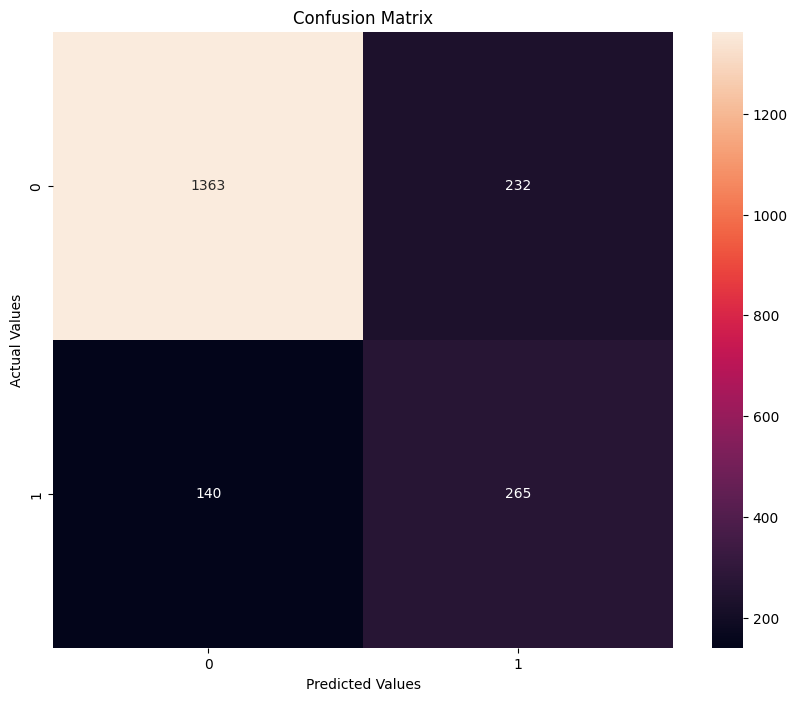

In [ ]:
cm = tf.math.confusion_matrix(y_test, y_predict)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

In [ ]:
precision_for_0=round(1363/(1363+140),2)
precision_for_0

0.91

In [ ]:
precision_for_1=round(265/(232+265),2)
precision_for_1

0.53

In [ ]:
recall_for_0=round(1363/(1363+140),2)
recall_for_0

0.91

In [ ]:
recal1_for_1=round(265/(265+140),2)
recal1_for_1

0.65

In [ ]:
accuracy=round((1363+265)/(1363+140+265+140),2)
accuracy

0.85

In [ ]:
F1_SCORE_0=(2*precision_for_0*recall_for_0)/(precision_for_0+recall_for_0)
F1_SCORE_0


0.91

In [ ]:
F1_SCORE_1=(2*precision_for_1*recal1_for_1)/(precision_for_1+recal1_for_1)
F1_SCORE_1

0.5838983050847457